# Data Processing

This project phase involves compiling individual ESG metrics from Yahoo Finance and historical performance data from Bloomberg for each constituent of the XISR ETF.

In [63]:
!pip install yahoofinance
!git clone https://github.com/ArmandSDarmosusilo/Quantitative-ESG-Research-Project
!git -C Quantitative-ESG-Research-Project pull
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import Ridge
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    median_absolute_error,
    explained_variance_score,
    max_error
)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, PredefinedSplit

fatal: destination path 'Quantitative-ESG-Research-Project' already exists and is not an empty directory.
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 7 (delta 4), reused 5 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (7/7), 1.11 KiB | 566.00 KiB/s, done.
From https://github.com/ArmandSDarmosusilo/Quantitative-ESG-Research-Project
   66d7aea..f7e2d11  main       -> origin/main
Updating 66d7aea..f7e2d11
Fast-forward
 .DS_Store                                                | Bin 0 -> 6148 bytes
 ...ompilasi_ESG_Scores_Saham_Portofolio_Sri_Kehati.xlsx} | Bin
 2 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 .DS_Store
 rename Data/{Copy of Kompilasi ESG Scores Saham Portofolio Sri Kehati.xlsx => Kompilasi_ESG_Scores_Saham_Portofolio_Sri_Kehati.xlsx} (100%)


XISR Price Graph:


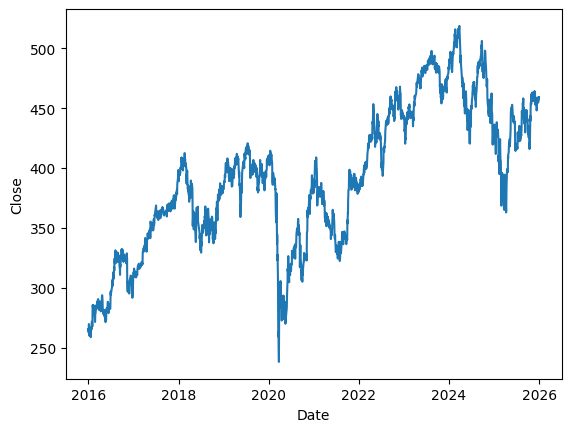


XISR Price Table:


,Ticker,Year,Date,Close,Percent_Change
0,IXISR,2015,2015-12-30,265.5348,NaN
1,IXISR,2016,2016-01-04,262.7626,-0.010440
2,IXISR,2016,2016-01-05,266.3237,0.013553
3,IXISR,2016,2016-01-06,269.8472,0.013230
4,IXISR,2016,2016-01-07,263.6682,-0.022898
...,...,...,...,...,...
2410,IXISR,2025,2025-12-22,458.6631,0.001129
2411,IXISR,2025,2025-12-23,454.6117,-0.008833
2412,IXISR,2025,2025-12-24,455.6863,0.002364
2413,IXISR,2025,2025-12-29,457.6045,0.004209


In [55]:
xisr_data = pd.read_csv("Quantitative-ESG-Research-Project/Data/XISR_primary_price.csv",sep=";",decimal=",")

xisr_data = xisr_data.rename(columns={
    "sec": "Ticker",
    "sdate": "Date",
    "NAV BK DB": "Close"
})

xisr_data["Date"] = pd.to_datetime(xisr_data["Date"], errors="coerce")
xisr_data["Close"] = pd.to_numeric(xisr_data["Close"], errors='coerce')

xisr_data = xisr_data.dropna(subset=["Date", "Ticker", "Close"])
xisr_data = xisr_data.sort_values("Date")

xisr_data["Percent_Change"] = xisr_data["Close"].pct_change()
xisr_data["Year"] = xisr_data["Date"].dt.year

xisr_data = xisr_data.reindex(columns=["Ticker", "Year", "Date", "Close", "Percent_Change"])

sb.lineplot(data=xisr_data, x="Date", y="Close")
print("XISR Price Graph:")
plt.show()

print("\nXISR Price Table:")
display(xisr_data)

XIIT Price Graph:


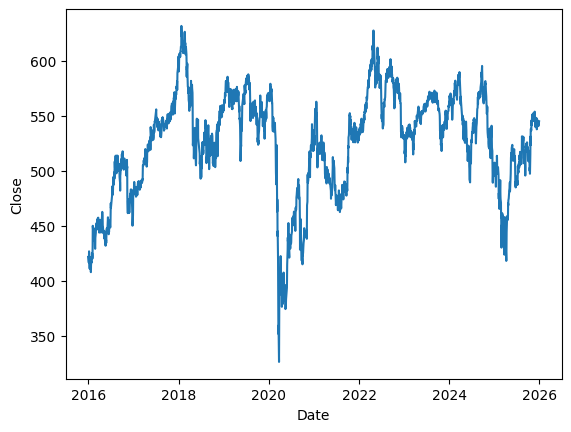


XIIT Price Table:


,Ticker,Year,Date,Close,Percent_Change
0,IXIIT,2015,2015-12-30,421.8174,NaN
1,IXIIT,2016,2016-01-04,416.5835,-0.012408
2,IXIIT,2016,2016-01-05,420.4095,0.009184
3,IXIIT,2016,2016-01-06,426.8707,0.015369
4,IXIIT,2016,2016-01-07,417.4631,-0.022039
...,...,...,...,...,...
2410,IXIIT,2025,2025-12-22,545.6347,0.003441
2411,IXIIT,2025,2025-12-23,541.3807,-0.007796
2412,IXIIT,2025,2025-12-24,540.5964,-0.001449
2413,IXIIT,2025,2025-12-29,544.6697,0.007535


In [56]:
xiit_data = pd.read_csv("Quantitative-ESG-Research-Project/Data/XIIT_primary_price.csv",sep=";",decimal=",")

xiit_data = xiit_data.rename(columns={
    "sec": "Ticker",
    "sdate": "Date",
    "NAV BK DB": "Close"
})

xiit_data["Date"] = pd.to_datetime(xiit_data["Date"], errors="coerce")
xiit_data["Close"] = pd.to_numeric(xiit_data["Close"], errors='coerce')

xiit_data = xiit_data.dropna(subset=["Date", "Ticker", "Close"])
xiit_data = xiit_data.sort_values("Date")

xiit_data["Percent_Change"] = xiit_data["Close"].pct_change()
xiit_data["Year"] = xiit_data["Date"].dt.year

xiit_data = xiit_data.reindex(columns=["Ticker", "Year", "Date", "Close", "Percent_Change"])

sb.lineplot(data=xiit_data, x="Date", y="Close")
print("XIIT Price Graph:")
plt.show()

print("\nXIIT Price Table:")
display(xiit_data)

XISR vs XIIT Price Comparison:


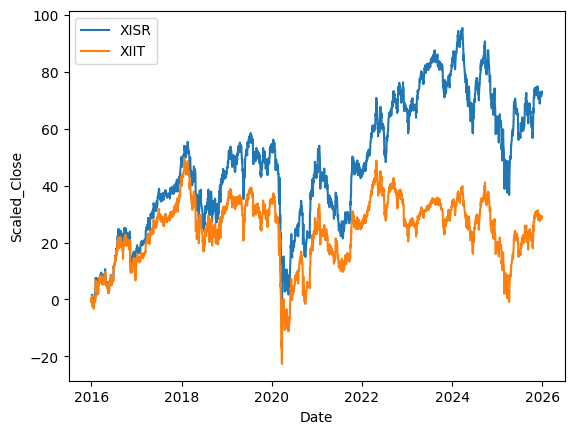

In [57]:
xisr_scaled = xisr_data.copy()
xisr_scaled["Scaled_Close"] = xisr_scaled["Close"]*100/xisr_scaled["Close"].iloc[0]-100

xiit_scaled = xiit_data.copy()
xiit_scaled["Scaled_Close"] = xiit_scaled["Close"]*100/xiit_scaled["Close"].iloc[0]-100

sb.lineplot(data=xisr_scaled, x="Date", y="Scaled_Close", label="XISR")
sb.lineplot(data=xiit_scaled, x="Date", y="Scaled_Close", label="XIIT")
print("XISR vs XIIT Price Comparison:")
plt.show()

In [58]:
xisr_ystats = xisr_data.copy()
xisr_ystats = xisr_data.groupby("Year").tail(1)
xisr_ystats = xisr_ystats[["Year", "Close"]]
xisr_ystats["Returns"] = (xisr_ystats["Close"]-xisr_ystats["Close"].shift(1))/xisr_ystats["Close"].shift(1)
xisr_ystats["Volatility"] = range(len(xisr_ystats))
xisr_ystats["Max_Drawdown"] = range(len(xisr_ystats))
xisr_ystats["Sharpe_Ratio"] = range(len(xisr_ystats))

rf_rate = 0.065

xisr_index = list(xisr_ystats.index)
stdev_group = [np.nan]
drawdown_group = [np.nan]

for i in range(len(xisr_index)):
  if i+1 == len(xisr_index):
    continue

  else:
    start = xisr_index[i]
    stop = xisr_index[i+1]
    stdev_group.append(xisr_data.loc[start:stop, "Percent_Change"].std() * np.sqrt(252))

for i in range(len(xisr_index)):
  if i+1 == len(xisr_index):
    continue

  else:
    start = xisr_index[i]
    stop = xisr_index[i+1]

    max_value = xisr_data.loc[start:stop, "Close"].max()
    min_value = xisr_data.loc[start:stop, "Close"].min()

    drawdown_value = (min_value-max_value)/max_value
    drawdown_group.append(drawdown_value)

xisr_ystats["Volatility"] = stdev_group
xisr_ystats["Max_Drawdown"] = drawdown_group
xisr_ystats["Sharpe_Ratio"] = (xisr_ystats["Returns"]-rf_rate)/xisr_ystats["Volatility"]

display(xisr_ystats)

print("\nMean Sharpe Ratio:")
print(xisr_ystats["Sharpe_Ratio"].mean())

,Year,Close,Returns,Volatility,Max_Drawdown,Sharpe_Ratio
0,2015,265.5348,NaN,NaN,NaN,NaN
246,2016,312.4394,0.176642,0.182114,-0.220971,0.613033
483,2017,398.3969,0.275117,0.113228,-0.224853,1.855704
723,2018,382.2391,-0.040557,0.213414,-0.201413,-0.494611
967,2019,407.0104,0.064806,0.149301,-0.146349,-0.001301
1209,2020,379.2923,-0.068102,0.357834,-0.425302,-0.371965
1456,2021,379.9922,0.001845,0.181470,-0.211491,-0.348017
1702,2022,442.3348,0.164063,0.150485,-0.188057,0.658289
1941,2023,483.2007,0.092387,0.111510,-0.155473,0.245600
2178,2024,431.2648,-0.107483,0.167266,-0.191055,-1.031191



Mean Sharpe Ratio:
0.11256425232133352


In [59]:
xiit_ystats = xiit_data.copy()
xiit_ystats = xiit_data.groupby("Year").tail(1)
xiit_ystats = xiit_ystats[["Year", "Close"]]
xiit_ystats["Returns"] = (xiit_ystats["Close"]-xiit_ystats["Close"].shift(1))/xiit_ystats["Close"].shift(1)
xiit_ystats["Volatility"] = range(len(xiit_ystats))
xiit_ystats["Max_Drawdown"] = range(len(xiit_ystats))
xiit_ystats["Sharpe_Ratio"] = range(len(xiit_ystats))

rf_rate = 0.065

xiit_index = list(xiit_ystats.index)
stdev_group = [np.nan]
drawdown_group = [np.nan]

for i in range(len(xiit_index)):
  if i+1 == len(xiit_index):
    continue

  else:
    start = xiit_index[i]
    stop = xiit_index[i+1]
    stdev_group.append(xiit_data.loc[start:stop, "Percent_Change"].std() * np.sqrt(252))

for i in range(len(xiit_index)):
  if i+1 == len(xiit_index):
    continue

  else:
    start = xiit_index[i]
    stop = xiit_index[i+1]

    max_value = xiit_data.loc[start:stop, "Close"].max()
    min_value = xiit_data.loc[start:stop, "Close"].min()

    drawdown_value = (min_value-max_value)/max_value
    drawdown_group.append(drawdown_value)

xiit_ystats["Volatility"] = stdev_group
xiit_ystats["Max_Drawdown"] = drawdown_group
xiit_ystats["Sharpe_Ratio"] = (xiit_ystats["Returns"]-rf_rate)/xiit_ystats["Volatility"]

display(xiit_ystats)

print("\nMean Sharpe Ratio:")
print(xiit_ystats["Sharpe_Ratio"].mean())

,Year,Close,Returns,Volatility,Max_Drawdown,Sharpe_Ratio
0,2015,421.8174,NaN,NaN,NaN,NaN
246,2016,481.1796,0.140730,0.179302,-0.212047,0.422357
483,2017,603.7912,0.254815,0.113788,-0.210791,1.668145
723,2018,554.4156,-0.081776,0.215164,-0.219707,-0.682158
967,2019,565.7638,0.020469,0.150856,-0.133983,-0.295191
1209,2020,518.4217,-0.083678,0.364627,-0.436377,-0.407754
1456,2021,527.6483,0.017797,0.177938,-0.178134,-0.265275
1702,2022,531.0179,0.006386,0.155365,-0.159125,-0.377265
1941,2023,557.9658,0.050748,0.116487,-0.113787,-0.122351
2178,2024,500.2938,-0.103361,0.166021,-0.178201,-1.014098



Mean Sharpe Ratio:
-0.09661685185366256


In [60]:
stock_list = ["BBCA.JK",
              "BBNI.JK",
              "BBRI.JK",
              "BMRI.JK",
              "INDF.JK",
              "JSMR.JK",
              "KLBF.JK",
              "SMGR.JK",
              "UNVR.JK",
              "ASII.JK",
              "TLKM.JK",
              "ICBP.JK",
              "ANTM.JK",
              "PGAS.JK"]

all_data = []

for i in range(len(stock_list)):
    stock = yf.download(
        stock_list[i],
        start="2015-12-30",
        end="2025-12-31",
        auto_adjust=True,
        progress=False
    )

    stock = stock.reset_index()

    temp = pd.DataFrame({
        "Ticker": [stock_list[i]] * len(stock),
        "Year": stock["Date"].dt.year,
        "Date": stock["Date"],
        "Close": stock["Close"].squeeze(),
        "Percent_Change": stock["Close"].squeeze().pct_change(),
    })

    temp_ystats = temp.copy()
    temp_ystats = temp.groupby("Year").tail(1)
    temp_ystats = temp_ystats[["Ticker", "Year", "Close"]]
    temp_ystats["Returns"] = temp_ystats["Close"].pct_change()
    temp_ystats["Volatility"] = range(len(temp_ystats))
    temp_ystats["Max_Drawdown"] = range(len(temp_ystats))
    temp_ystats["Sharpe_Ratio"] = range(len(temp_ystats))

    temp_index = list(temp_ystats.index)
    stdev_group = [np.nan]
    drawdown_group = [np.nan]

    for j in range(len(temp_index)):
      if j+1 == len(temp_index):
        continue

      else:
        start = temp_index[j]
        stop = temp_index[j+1]
        stdev_group.append(temp.loc[start:stop, "Percent_Change"].std() * np.sqrt(252))

    for j in range(len(temp_index)):
      if j+1 == len(temp_index):
        continue

      else:
        start = temp_index[j]
        stop = temp_index[j+1]

        max_value = temp.loc[start:stop, "Close"].max()
        min_value = temp.loc[start:stop, "Close"].min()

        drawdown_value = (min_value-max_value)/max_value
        drawdown_group.append(drawdown_value)

    temp_ystats["Volatility"] = stdev_group
    temp_ystats["Max_Drawdown"] = drawdown_group
    temp_ystats["Sharpe_Ratio"] = ((temp_ystats["Returns"]-0.065)/temp_ystats["Volatility"])
    temp_ystats["Future_Sharpe"] = temp_ystats["Sharpe_Ratio"].shift(-1)
    temp_ystats["Future_Returns"] = temp_ystats["Returns"].shift(-1)

    all_data.append(temp_ystats)

stock_data = pd.concat(all_data, ignore_index=True)
stock_data["Ticker"] = stock_data["Ticker"].str.lower().str.replace(".jk", "")

display(stock_data)

print("\nMean Sharpe Ratio:")
print(stock_data["Sharpe_Ratio"].mean())

,Ticker,Year,Close,Returns,Volatility,Max_Drawdown,Sharpe_Ratio,Future_Sharpe,Future_Returns
0,bbca,2015,2092.760010,NaN,NaN,NaN,NaN,0.731606,0.180646
1,bbca,2016,2470.809082,0.180646,0.158072,-0.211999,0.731606,1.958864,0.428937
2,bbca,2017,3530.629639,0.428937,0.185790,-0.325781,1.958864,0.617566,0.200174
3,bbca,2018,4237.368164,0.200174,0.218881,-0.219286,0.617566,1.562406,0.301435
4,bbca,2019,5514.657227,0.301435,0.151327,-0.242504,1.562406,-0.083070,0.033343
...,...,...,...,...,...,...,...,...,...
149,pgas,2021,875.115051,-0.169184,0.426358,-0.461326,-0.549267,0.870074,0.376486
150,pgas,2022,1204.583374,0.376486,0.357999,-0.399682,0.870074,-1.341761,-0.287693
151,pgas,2023,858.032715,-0.287693,0.262859,-0.328667,-1.341761,1.640418,0.551825
152,pgas,2024,1331.516479,0.551825,0.296769,-0.415189,1.640418,0.877591,0.329700



Mean Sharpe Ratio:
0.10894138403352578


In [64]:
sheet_names = pd.ExcelFile("Quantitative-ESG-Research-Project/Data/Kompilasi_ESG_Scores_Saham_Portofolio_Sri_Kehati.xlsx").sheet_names

sheet_names

esg_data = []

for i in sheet_names:
  df_sheet = pd.read_excel("Quantitative-ESG-Research-Project/Data/Kompilasi_ESG_Scores_Saham_Portofolio_Sri_Kehati.xlsx", sheet_name=i)
  df_sheet_data = df_sheet.iloc[5:9, 2:11]

  years = df_sheet.iloc[2, 2:11].tolist()
  df_sheet_data.columns = years
  df_sheet_data["Ticker"] = i
  df_sheet_data["ESG"] = df_sheet.iloc[5:9, 1].tolist()

  esg_data.append(df_sheet_data)

all_esg_data = pd.concat(esg_data, ignore_index=True)
all_esg_data = all_esg_data[[
    'Ticker', "ESG", "FY 2015", "FY 2016", "FY 2017", "FY 2018", "FY 2019", "FY 2020", "FY 2021", "FY 2022", "FY 2023", "FY 2024", "FY 2025"
]]

display(all_esg_data)

,Ticker,ESG,FY 2015,FY 2016,FY 2017,FY 2018,FY 2019,FY 2020,FY 2021,FY 2022,FY 2023,FY 2024,FY 2025
0,bbca,ESG_DISCLOSURE_SCORE,NaN,44.6032,46.2428,47.2991,55.7288,55.7288,59.32,58.7164,60.1549,61.9052,NaN
1,bbca,ENVIRON_DISCLOSURE_SCORE,NaN,8.0338,8.0338,11.2051,25.5814,25.5814,30.9272,30.9272,28.9641,32.4071,NaN
2,bbca,SOCIAL_DISCLOSURE_SCORE,NaN,42.0496,46.977,46.977,51.6324,51.6324,57.0738,55.26,55.26,57.0738,NaN
3,bbca,GOVNCE_DISCLOSURE_SCORE,NaN,83.5942,83.5942,83.5942,89.8555,89.8555,89.8555,89.8555,96.1168,96.1168,NaN
4,bmri,ESG_DISCLOSURE_SCORE,NaN,37.0285,39.4226,43.8085,47.2186,48.134,52.1577,53.566,53.2039,—,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,powr,GOVNCE_DISCLOSURE_SCORE,NaN,—,—,—,—,—,87.357,87.357,87.357,87.357,NaN
112,untr,ESG_DISCLOSURE_SCORE,NaN,NaN,"38,41","39,26","45,22","44,09","51,40","49,17","49,30","49,30",NaN
113,untr,ENVIRON_DISCLOSURE_SCORE,NaN,"6,64","6,64","6,64","21,96","18,57","25,70","20,54","20,54","20,54",NaN
114,untr,SOCIAL_DISCLOSURE_SCORE,NaN,"28,20","27,21","29,78","32,35","32,35","44,80","43,26","43,65","43,65",NaN


In [65]:
all_esg_data_long = all_esg_data.melt(
    id_vars = ["Ticker", "ESG"],
    var_name = "Year",
    value_name = "Score"
)

all_esg_data_long["Year"] = (
    all_esg_data_long["Year"]
    .str.replace("FY ", "", regex=False)
    .astype(int)
)

all_esg_data_final = all_esg_data_long.pivot_table(
    index = ["Ticker", "Year"],
    columns = "ESG",
    values = "Score",
    aggfunc = "first",
    sort = False
).reset_index()

all_esg_data_final.columns.name = None

display(all_esg_data_final)

,Ticker,Year,ESG_DISCLOSURE_SCORE,ENVIRON_DISCLOSURE_SCORE,SOCIAL_DISCLOSURE_SCORE,GOVNCE_DISCLOSURE_SCORE
0,bbca,2016,44.6032,8.0338,42.0496,83.5942
1,bbca,2017,46.2428,8.0338,46.977,83.5942
2,bbca,2018,47.2991,11.2051,46.977,83.5942
3,bbca,2019,55.7288,25.5814,51.6324,89.8555
4,bbca,2020,55.7288,25.5814,51.6324,89.8555
...,...,...,...,...,...,...
252,untr,2020,"44,09","18,57","32,35","81,22"
253,untr,2021,"51,40","25,70","44,80","83,59"
254,untr,2022,"49,17","20,54","43,26","83,59"
255,untr,2023,"49,30","20,54","43,65","83,59"


In [66]:
df_final = pd.merge(left=all_esg_data_final, right=stock_data, left_on=["Ticker", "Year"], right_on=["Ticker", "Year"], how="inner")
df_final = df_final.drop(columns=["Close", "Max_Drawdown"])

df_final = df_final.replace("—", pd.NA)
df_final = df_final.dropna().reset_index(drop=True)

df_final.to_csv("/content/contentdrive/MyDrive/ESG_Project_Data/esg_stock.csv")

print("ESG and Sharpe Ratio data:")
display(df_final)

ESG and Sharpe Ratio data:


,Ticker,Year,ESG_DISCLOSURE_SCORE,ENVIRON_DISCLOSURE_SCORE,SOCIAL_DISCLOSURE_SCORE,GOVNCE_DISCLOSURE_SCORE,Returns,Volatility,Sharpe_Ratio,Future_Sharpe,Future_Returns
0,bbca,2016,44.6032,8.0338,42.0496,83.5942,0.180646,0.158072,0.731606,1.958864,0.428937
1,bbca,2017,46.2428,8.0338,46.977,83.5942,0.428937,0.185790,1.958864,0.617566,0.200174
2,bbca,2018,47.2991,11.2051,46.977,83.5942,0.200174,0.218881,0.617566,1.562406,0.301435
3,bbca,2019,55.7288,25.5814,51.6324,89.8555,0.301435,0.151327,1.562406,-0.083070,0.033343
4,bbca,2020,55.7288,25.5814,51.6324,89.8555,0.033343,0.381091,-0.083070,0.139081,0.097071
...,...,...,...,...,...,...,...,...,...,...,...
118,jsmr,2020,50.5382,33.7964,34.0992,83.5942,-0.102008,0.552757,-0.302136,-0.704697,-0.159827
119,jsmr,2021,56.2821,51.042,34.0992,83.5942,-0.159827,0.319041,-0.704697,-1.058686,-0.233933
120,jsmr,2022,60.2052,49.0788,47.8537,83.5942,-0.233933,0.282362,-1.058686,1.862996,0.670353
121,jsmr,2023,61.4123,49.0788,51.4813,83.5942,0.670353,0.324935,1.862996,-0.576506,-0.104099
